## 📝 Polinom Regresyon 
---
### Müşteri Memnuniyeti ve Teşvik (Incentive) Optimizasyonu: Polinom Regresyon (Polynomial Regression)

Bu projede, müşterilerin memnuniyet skorları ile onlara sunulan teşvik (incentive) miktarları arasındaki doğrusal olmayan (non-linear) ilişki modellenmiştir. Basit Doğrusal Regresyonun (Linear Regression) yetersiz kaldığı **(underfitting)** durumlarda, veri setindeki kavisli yapıyı yakalamak için **Polinom Regresyon** uygulanmış ve Scikit-Learn Pipeline mimarisi kullanılarak modelin derecesi (degree) 1'den 10'a kadar optimize edilmiştir.

---

### 💻 Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Görselleştirme Ayarları
sns.set_theme(style="whitegrid",palette= "muted")
plt.rcParams['figure.dpi'] = 100

# Makine Öğrenimi 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from sklearn.pipeline import Pipeline

### 📝 Veri Yükleme ve EDA
---

#### 2. Veri Yükleme ve Keşifsel Analiz (EDA)
Veriyi yüklüyor, gereksiz indeks kolonlarını temizliyor ve Müşteri Memnuniyeti ile Teşvik arasındaki ilişkiyi görselleştiriyoruz.

Grafikte de net bir şekilde görüleceği üzere, iki değişken arasında "U" veya "J" şekline benzeyen doğrusal olmayan (non-linear) bir ilişki bulunmaktadır. Bu durum, veri setinin standart bir çizgi ile modellenemeyeceğinin en net kanıtıdır.

### 💻 Veri Yükleme

In [2]:
# Veriyi Yükleme
df = pd.read_csv("3-customersatisfaction.csv")

# Gereksiz index kolonunu temizleme 
df.drop("Unnamed: 0" , inplace=True, axis=1 )

In [3]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


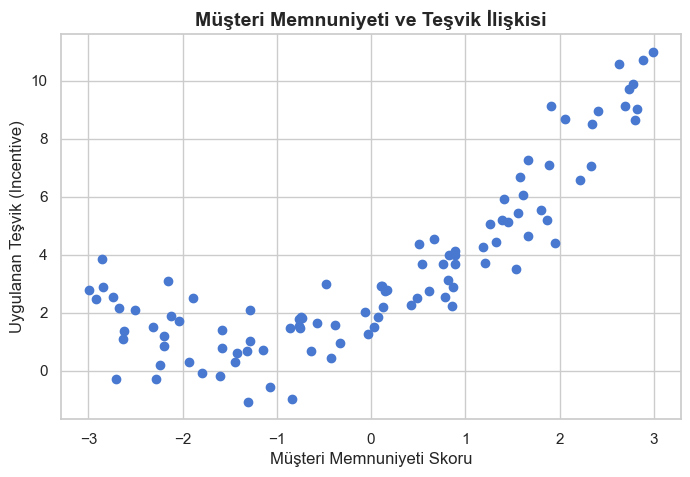

In [5]:
# Değişkenler Arası İlişkinin Görselleştirilmesi
plt.figure(figsize=(8,5))
plt.scatter(x = df["Customer Satisfaction"], y = df["Incentive"])
plt.title("Müşteri Memnuniyeti ve Teşvik İlişkisi", fontsize=14, fontweight="bold")
plt.xlabel("Müşteri Memnuniyeti Skoru")
plt.ylabel("Uygulanan Teşvik (Incentive)")
plt.show()

### 📝 Veri Hazırlığı ve Baseline Model
---
#### 3. Doğrusal Regresyon (Baseline Model - Underfitting)

Referans noktamızı (baseline) belirlemek adına önce standart bir Basit Doğrusal Regresyon eğitiyoruz.

💡Not: Doğrusal modeller kavisli verileri düz bir çizgi ile kesmeye çalışır. Bu duruma Yetersiz Öğrenme (Underfitting) denir ve R² skorunun çok düşük çıkması beklenir.

### 💻 Linear Regression

In [6]:
# Bağımsız (X) ve Bağımlı (y) Değişkenlerin Ayrılması
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [7]:
# Train/Test Bölünmesi
X_train , X_test , y_train , y_test = train_test_split(X,y ,test_size=0.2,random_state=42)

In [8]:
# Ölçeklendirme (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Basit Doğrusal Regresyon Modeli
linear_model = LinearRegression()

In [10]:
linear_model.fit(X_train_scaled , y_train )

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred_linear = linear_model.predict(X_test_scaled)
print(f"📉 Doğrusal Regresyon R² Skoru: {r2_score(y_test, y_pred_linear):.4f}")

📉 Doğrusal Regresyon R² Skoru: 0.7374


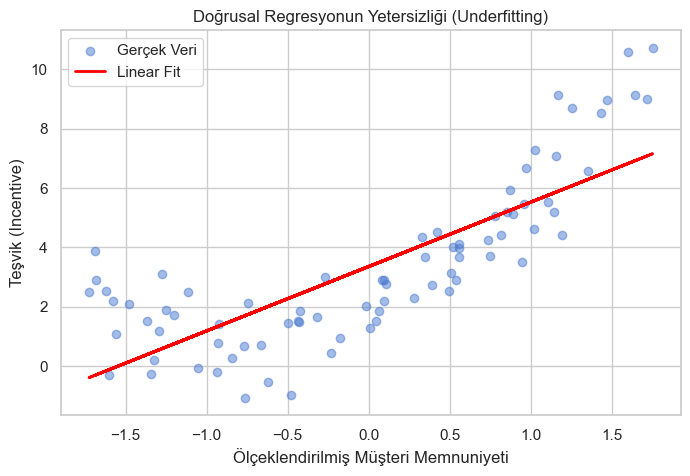

In [12]:
# Basit modelin başarısızlığını görselleştirme
plt.figure(figsize=(8,5))
plt.scatter(x = X_train_scaled, y=  y_train, label="Gerçek Veri", alpha=0.5)
plt.plot(X_train_scaled, linear_model.predict(X_train_scaled), color="red", linewidth=2, label="Linear Fit")
plt.title("Doğrusal Regresyonun Yetersizliği (Underfitting)", fontsize=12)
plt.xlabel("Ölçeklendirilmiş Müşteri Memnuniyeti")
plt.ylabel("Teşvik (Incentive)")
plt.legend()
plt.show()

### 📝 Polynomial Pipeline Açıklaması
---

#### 4. Polinom Regresyon ve Model Optimizasyonu (Pipeline)

Kavisli yapıyı yakalamak için PolynomialFeatures kullanarak Müşteri Memnuniyeti değişkeninin karesini ($x^2$), küpünü ($x^3$) vb. alarak modele yeni özellikler ekleyeceğiz.

💡**Not (Neden np.linspace kullandık?):** Regresyon eğrisini (curve) pürüzsüz bir çizgi şeklinde görselleştirebilmek için, X ekseninde sıralı ve kesintisiz verilere ihtiyacımız vardır. Bu nedenle dışarıdan sahte bir CSV dosyası ("new data") yüklemek yerine, Numpy'ın **np.linspace** fonksiyonu ile X ekseninin **min** ve **max** değerleri arasında pürüzsüz sanal bir eksen (X_plot) oluşturduk.Ayrıca tüm işlemleri (Ölçeklendirme $\rightarrow$ Polinom Dönüşümü $\rightarrow$ Model Eğitimi) bir Scikit-Learn Pipeline içerisine alarak kodumuzu endüstri standardına taşıdık. Bu sayede Veri Sızıntısı **(Data Leakage)** riskini tamamen sıfırladık.

---

### 💻 Pipeline ve Eğri Görselleştirme Döngüsü

🎯 Pipeline tabanlı Polinom Regresyon eğitimleri ve metrik analizi başladı...



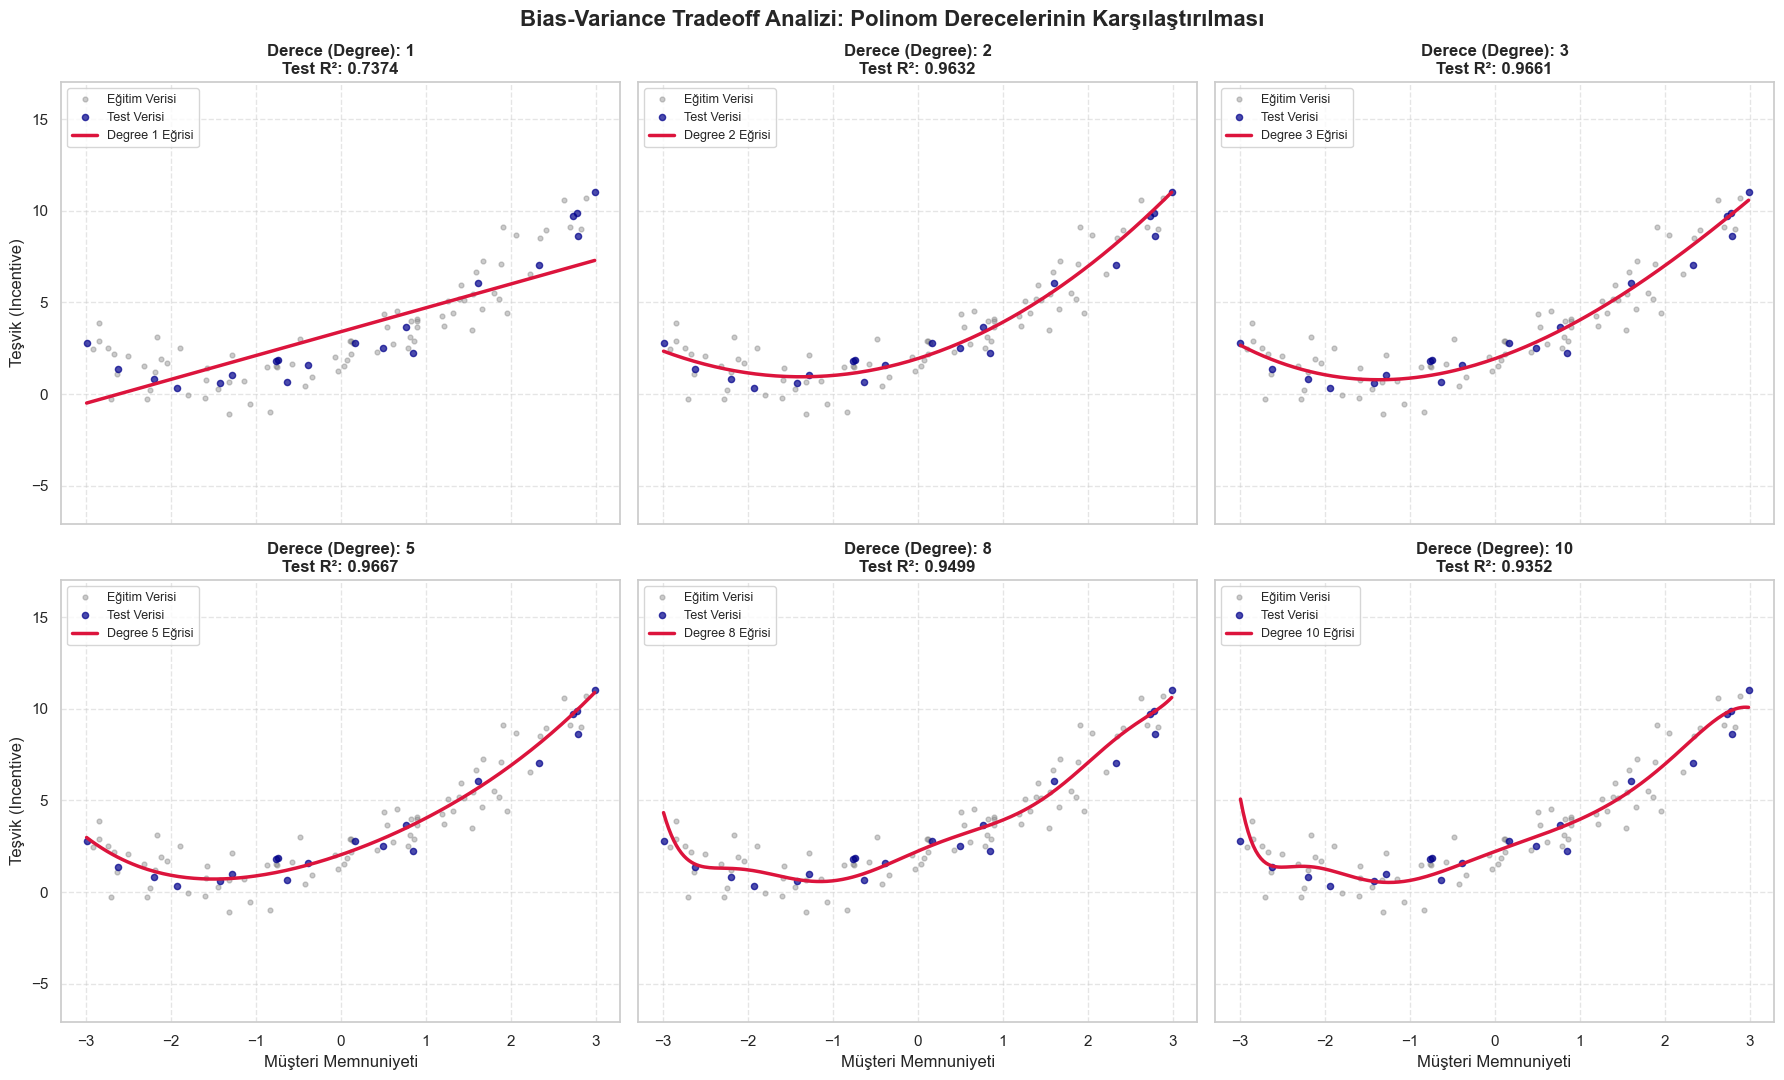

In [13]:
X_plot_array = np.linspace(df['Customer Satisfaction'].min(), df['Customer Satisfaction'].max(), 200)

X_plot = pd.DataFrame(X_plot_array, columns=['Customer Satisfaction'])

# Test edilecek polinom dereceleri
degrees = [1, 2, 3, 5, 8, 10]

# Performans metriklerini depolamak için liste
performance_logs = []

# Tüm modelleri tek bir 2x3'lük matris düzeninde görselleştiriyoruz
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True, sharey=True)
axes = axes.flatten()

print("🎯 Pipeline tabanlı Polinom Regresyon eğitimleri ve metrik analizi başladı...\n")

for idx, deg in enumerate(degrees):
    # 1. Pipeline Mimarisinin Kurulması
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("poly_features", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linear_regression", LinearRegression())
    ])
    
    # 2. Model Eğitimi (Pipeline veri sızıntısını otomatik engeller)
    pipeline.fit(X_train, y_train)
    
    # 3. Tahminlerin Üretilmesi
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    y_plot_pred = pipeline.predict(X_plot) # <-- Artık burada uyarı almayacaksınız
    
    # 4. Kapsamlı Metrik Hesaplamaları
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Metrikleri loglama (Pandas DataFrame için)
    performance_logs.append({
        "Polinom Derecesi (Degree)": deg,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "R2 Gap (Overfit Kontrolü)": train_r2 - test_r2
    })
    
    # 5. Alt Grafiklerin (Subplots) Çizimi
    ax = axes[idx]
    ax.scatter(X_train, y_train, color='gray', alpha=0.4, s=12, label="Eğitim Verisi")
    ax.scatter(X_test, y_test, color='darkblue', alpha=0.7, s=20, label="Test Verisi")
    
    # Çizim yaparken X_plot bir DataFrame olduğu için '.values' veya doğrudan kendisini kullanabiliriz
    ax.plot(X_plot['Customer Satisfaction'], y_plot_pred, color="crimson", linewidth=2.5, label=f"Degree {deg} Eğrisi")
    
    # Grafik İyileştirmeleri
    ax.set_title(f"Derece (Degree): {deg}\nTest R²: {test_r2:.4f}", fontsize=12, fontweight='bold')
    y_min, y_max = df['Incentive'].min(), df['Incentive'].max()
    margin = (y_max - y_min) * 0.5  # Veri aralığının %50'si kadar üstten/alttan boşluk bırak
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper left", fontsize=9)
    
    if idx >= 3: ax.set_xlabel("Müşteri Memnuniyeti")
    if idx % 3 == 0: ax.set_ylabel("Teşvik (Incentive)")

# Genel Başlık Düzenlemesi
fig.suptitle("Bias-Variance Tradeoff Analizi: Polinom Derecelerinin Karşılaştırılması", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()